# Import Dependencies...

In [55]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

print("Libraries Imported Successfully")

Libraries Imported Successfully


# Loading the Dataset

The Breast Cancer dataset is loaded into a Pandas DataFrame. This dataset contains medical measurements and diagnostic features that will be used to predict whether a tumor is malignant or benign.

In [56]:

bc_df = pd.read_csv("breast-cancer.csv")

bc_df.head()

,age,mefalsepause,tumor-size,inv-falsedes,falsede-caps,deg-malig,breast,breast-quad,irradiat,class
0,40-49,premefalse,15-19,0-2,True,3,right,left_up,False,recurrence-events
1,50-59,ge40,15-19,0-2,False,1,right,central,False,false-recurrence-events
2,50-59,ge40,35-39,0-2,False,2,left,left_low,False,recurrence-events
3,40-49,premefalse,35-39,0-2,True,3,right,left_low,True,false-recurrence-events
4,40-49,premefalse,30-34,3-5,True,2,left,right_up,False,recurrence-events


# Dataset Exploration

Before building the machine learning models, the dataset is examined to understand its structure, dimensions, data types, missing values, and overall quality.

In [57]:
# Dataset Shape

print("Dataset Shape:")
print(bc_df.shape)

# Column Names

print("Column Names:")
print(bc_df.columns)

# Missing Values

bc_df.isnull().sum()

Dataset Shape:
(272, 10)
Column Names:
Index(['age', 'mefalsepause', 'tumor-size', 'inv-falsedes', 'falsede-caps',
       'deg-malig', 'breast', 'breast-quad', 'irradiat', 'class'],
      dtype='object')


,0
age,0
mefalsepause,0
tumor-size,0
inv-falsedes,0
falsede-caps,8
deg-malig,0
breast,0
breast-quad,1
irradiat,0
class,0


In [58]:
# Duplicate Rows

print("Duplicate Rows:", bc_df.duplicated().sum())

Duplicate Rows: 0


In [59]:
# Statistical Summary

bc_df.describe()

,deg-malig
count,272.000000
mean,2.058824
std,0.736649
min,1.000000
25%,2.000000
50%,2.000000
75%,3.000000
max,3.000000


# Data Cleaning

The dataset contains a small number of missing values in the 'falsede-caps' and 'breast-quad' columns. These missing values will be replaced using the most frequent category (mode) of each feature. This preserves the dataset size while maintaining data consistency.

In [60]:
# MISSING VALUE TREATMENT

bc_df["falsede-caps"].fillna(
    bc_df["falsede-caps"].mode()[0],
    inplace=True
)

bc_df["breast-quad"].fillna(
    bc_df["breast-quad"].mode()[0],
    inplace=True
)

print("Missing Values After Cleaning:")
print(bc_df.isnull().sum())

Missing Values After Cleaning:
age             0
mefalsepause    0
tumor-size      0
inv-falsedes    0
falsede-caps    0
deg-malig       0
breast          0
breast-quad     0
irradiat        0
class           0
dtype: int64


/tmp/ipykernel_5533/2490059401.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  bc_df["falsede-caps"].fillna(
/tmp/ipykernel_5533/2490059401.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  bc_df["falsede-caps"].fillna(
/tmp/ipykernel_5533/2490059401.py:8: FutureWarning: A value is trying to be set on a c

# Target Variable Analysis

The class distribution is examined to understand whether the dataset is balanced or imbalanced. This helps in evaluating model performance correctly.

In [61]:
print(
    bc_df["class"].value_counts()
)

class
false-recurrence-events    191
recurrence-events           81
Name: count, dtype: int64


# Feature Inspection

Each categorical feature is inspected to identify the possible categories present in the dataset before encoding.

In [62]:
for col in bc_df.columns:
    print("\n", col)
    print(bc_df[col].unique())


 age
['40-49' '50-59' '60-69' '30-39' '70-79' '20-29']

 mefalsepause
['premefalse' 'ge40' 'lt40']

 tumor-size
['15-19' '35-39' '30-34' '25-29' '40-44' '10-14' '0-4' '20-24' '45-49'
 '50-54' '5-9']

 inv-falsedes
['0-2' '3-5' '15-17' '6-8' '9-11' '24-26' '12-14']

 falsede-caps
[ True False]

 deg-malig
[3 1 2]

 breast
['right' 'left']

 breast-quad
['left_up' 'central' 'left_low' 'right_up' 'right_low']

 irradiat
[False  True]

 class
['recurrence-events' 'false-recurrence-events']


# Feature Encoding

Most features in this dataset are categorical. Machine Learning algorithms require numerical input, so categorical values are converted into numerical representations using Label Encoding.

In [63]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in bc_df.columns:
    if bc_df[col].dtype == "object":
        bc_df[col] = le.fit_transform(
            bc_df[col]
        )

bc_df.head()

,age,mefalsepause,tumor-size,inv-falsedes,falsede-caps,deg-malig,breast,breast-quad,irradiat,class
0,2,2,2,0,True,3,1,2,False,1
1,3,0,2,0,False,1,1,0,False,0
2,3,0,6,0,False,2,0,1,False,1
3,2,2,6,0,True,3,1,1,True,0
4,2,2,5,4,True,2,0,4,False,1


In [64]:
bc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 272 entries, 0 to 271
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   age           272 non-null    int64
 1   mefalsepause  272 non-null    int64
 2   tumor-size    272 non-null    int64
 3   inv-falsedes  272 non-null    int64
 4   falsede-caps  272 non-null    bool 
 5   deg-malig     272 non-null    int64
 6   breast        272 non-null    int64
 7   breast-quad   272 non-null    int64
 8   irradiat      272 non-null    bool 
 9   class         272 non-null    int64
dtypes: bool(2), int64(8)
memory usage: 17.7 KB


# Target Class Distribution

The distribution of recurrence and non-recurrence cases is visualized to understand class balance within the dataset.

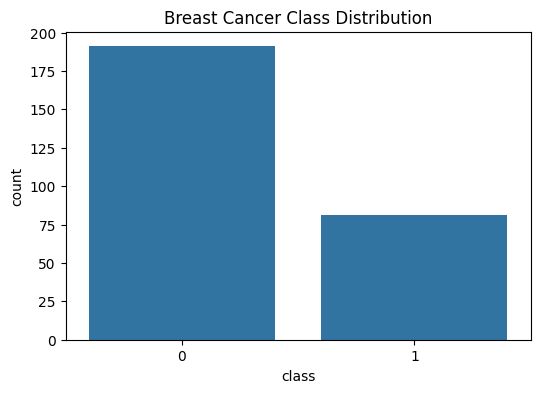

In [65]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="class",
    data=bc_df
)

plt.title("Breast Cancer Class Distribution")

plt.show()

# Correlation Analysis

A correlation heatmap is used to identify relationships between features and the target variable. Strongly correlated features may provide useful information for prediction.

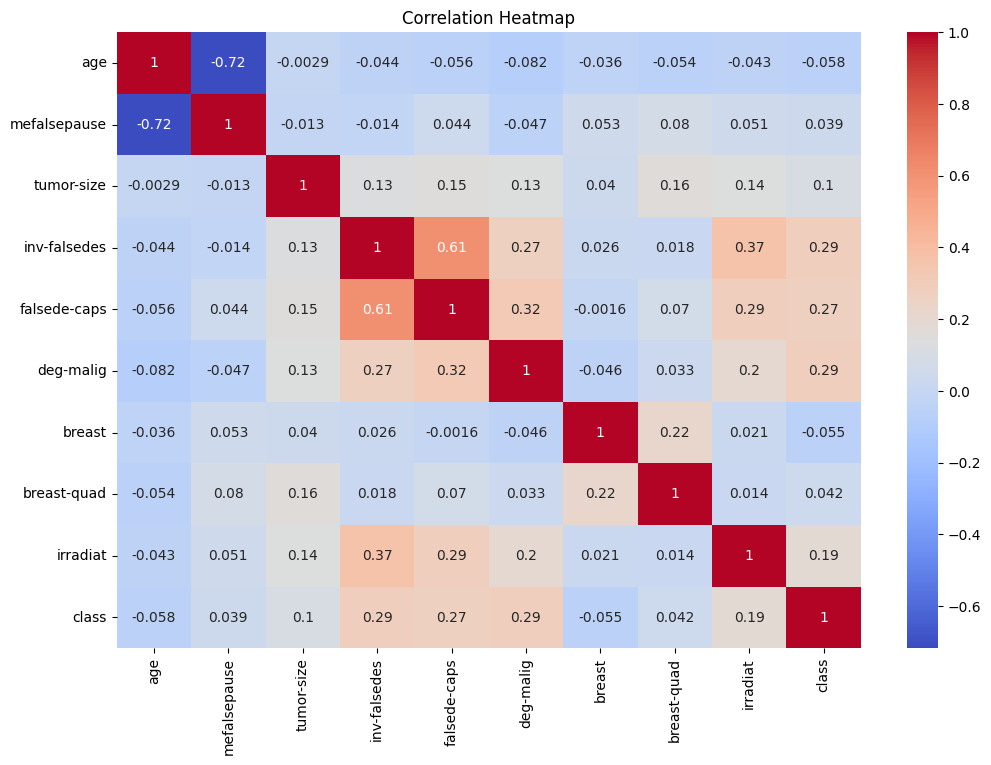

In [66]:
plt.figure(figsize=(12,8))

sns.heatmap(
    bc_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [67]:
# Feature Selection

X = bc_df.drop(
    "class",
    axis=1
)

y = bc_df["class"]

print("X Shape :", X.shape)
print("y Shape :", y.shape)

X Shape : (272, 9)
y Shape : (272,)


# Train-Test Split

The dataset is divided into training and testing sets. The training set is used to train the machine learning models, while the testing set is used to evaluate their performance on unseen data.

In [68]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (217, 9)
Testing Shape  : (55, 9)


# Feature Scaling

Feature scaling standardizes numerical features to a common scale. This improves the performance of algorithms such as Logistic Regression by preventing features with larger values from dominating the learning process.

In [69]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("Feature Scaling Completed")

Feature Scaling Completed


# Logistic Regression

Logistic Regression is a supervised machine learning algorithm used for binary classification problems. It predicts the probability of a sample belonging to a particular class.

In [70]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_model = LogisticRegression(max_iter=2000)

lr_model.fit(X_train, y_train)


LogisticRegression(max_iter=2000)

In [71]:

lr_pred = lr_model.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy :", lr_acc)

Logistic Regression Accuracy : 0.7454545454545455


# Random Forest

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [72]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [73]:
rf_pred = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy :", rf_acc)

Random Forest Accuracy : 0.6545454545454545


In [74]:
print("="*35)
print("MODEL COMPARISON")
print("="*35)

print("Logistic Regression :", lr_acc)
print("Random Forest       :", rf_acc)

MODEL COMPARISON
Logistic Regression : 0.7454545454545455
Random Forest       : 0.6545454545454545


# Confusion Matrix

A confusion matrix summarizes the prediction results by showing the number of correct and incorrect classifications for each class.

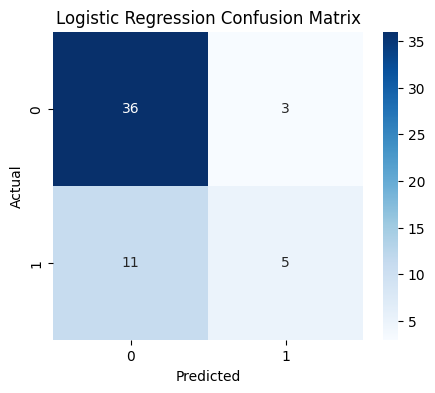

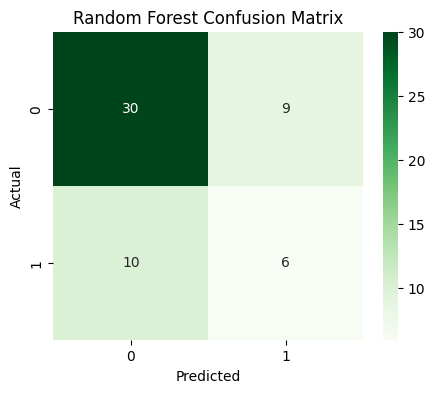

In [75]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Logistic Regression
plt.figure(figsize=(5,4))

sns.heatmap(
    confusion_matrix(y_test, lr_pred),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# Random Forest
plt.figure(figsize=(5,4))

sns.heatmap(
    confusion_matrix(y_test, rf_pred),
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report

The classification report provides precision, recall, F1-score, and accuracy metrics for evaluating model performance.

In [76]:
from sklearn.metrics import classification_report

print("========== Logistic Regression ==========\n")
print(classification_report(y_test, lr_pred))

print("\n========== Random Forest ==========\n")
print(classification_report(y_test, rf_pred))

========== Logistic Regression ==========

              precision    recall  f1-score   support

           0       0.77      0.92      0.84        39
           1       0.62      0.31      0.42        16

    accuracy                           0.75        55
   macro avg       0.70      0.62      0.63        55
weighted avg       0.72      0.75      0.71        55


========== Random Forest ==========

              precision    recall  f1-score   support

           0       0.75      0.77      0.76        39
           1       0.40      0.38      0.39        16

    accuracy                           0.65        55
   macro avg       0.57      0.57      0.57        55
weighted avg       0.65      0.65      0.65        55



# Model Evaluation

Logistic Regression Accuracy : 75%

Random Forest Accuracy : 65%

Logistic Regression performed better and was selected as the final model for Breast Cancer Prediction.

# Random / Manual Prediction Test...

In [82]:
import random

print("Random Prediction Test\n")

for i in random.sample(range(len(X_test)), 15):

    sample = X_test[i].reshape(1, -1)

    actual = y_test.iloc[i]

    pred = lr_model.predict(sample)[0]

    print(
        f"Actual: {actual} | Predicted: {pred} |",
        "✅ Correct" if pred == actual else "❌ Wrong"
    )

Random Prediction Test

Actual: 0 | Predicted: 1 | ❌ Wrong
Actual: 0 | Predicted: 0 | ✅ Correct
Actual: 0 | Predicted: 0 | ✅ Correct
Actual: 0 | Predicted: 0 | ✅ Correct
Actual: 0 | Predicted: 0 | ✅ Correct
Actual: 0 | Predicted: 0 | ✅ Correct
Actual: 1 | Predicted: 1 | ✅ Correct
Actual: 0 | Predicted: 0 | ✅ Correct
Actual: 1 | Predicted: 0 | ❌ Wrong
Actual: 0 | Predicted: 0 | ✅ Correct
Actual: 0 | Predicted: 0 | ✅ Correct
Actual: 0 | Predicted: 0 | ✅ Correct
Actual: 1 | Predicted: 0 | ❌ Wrong
Actual: 0 | Predicted: 0 | ✅ Correct
Actual: 0 | Predicted: 0 | ✅ Correct


In [78]:
import pickle

pickle.dump(lr_model, open("breast_cancer_model.pkl", "wb"))

print("Model Saved Successfully")

Model Saved Successfully


#Model Saving

The final Logistic Regression model was serialized using Pickle and saved as a .pkl file. This allows the trained model to be reused later without retraining.

In [79]:
from google.colab import files

files.download("breast_cancer_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>